# Student Group Project: High Utility Sequential Pattern Mining
## Scenario: Online Learning Platform Journey
In this project, your group will analyze a sequence dataset that represents student activity on an online learning platform. Use `husp_sequence_data.csv` as the source data and build a short presentation around the patterns you discover.

## Project Background
Imagine a learning platform that wants to improve course recommendations, study reminders, and support messages. Each row in the dataset is one activity in a student's journey, and the utility value can represent engagement, value, or importance.

## What Your Group Should Do
1. Load the CSV file and inspect the columns.
2. Reconstruct each student sequence in order.
3. Summarize which items appear most often and which have the highest utility.
4. Mine short high-utility sequences.
5. Turn the result into a simple recommendation for the platform.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

## Step 1: Import and Load Data
Write code here to import the libraries you need and load `husp_sequence_data.csv` from the `exercises datasets` folder. Then preview the first few rows.

In [2]:
# Load the data
df = pd.read_csv('husp_sequence_data.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (49, 4)

First 10 rows:
   transaction_id  sequence_order             item  utility
0               1               1            login        5
1               1               2      watch_video       25
2               1               3        take_quiz       40
3               2               1            login        5
4               2               2   download_notes       10
5               2               3      watch_video       25
6               3               1            login        5
7               3               2  join_live_class       35
8               3               3       post_forum       12
9               4               1            login        5

Data types:
transaction_id    int64
sequence_order    int64
item                str
utility           int64
dtype: object

Basic statistics:
       transaction_id  sequence_order    utility
count       49.000000       49.000000  49.000000
mean         8.346939        2.163265  20.897959
std         

## Step 2: Rebuild Student Sequences
Group the rows by transaction, sort by `sequence_order`, and turn each transaction into an ordered activity sequence.

You may print the sequences or store them in a dictionary or list.

In [3]:
# Sort by transaction_id and sequence_order
df_sorted = df.sort_values(['transaction_id', 'sequence_order'])

# Rebuild sequences as a dictionary
sequences = {}
for trans_id in df_sorted['transaction_id'].unique():
    trans_data = df_sorted[df_sorted['transaction_id'] == trans_id]
    # Store as list of (item, utility) tuples
    sequences[trans_id] = list(zip(trans_data['item'].values, trans_data['utility'].values))

# Print sample sequences
print("Sample Student Sequences:")
for trans_id in sorted(sequences.keys())[:5]:
    items = [item for item, util in sequences[trans_id]]
    utilities = [util for item, util in sequences[trans_id]]
    print(f"Student {trans_id}: {' → '.join(items)} (utilities: {utilities})")

Sample Student Sequences:
Student 1: login → watch_video → take_quiz (utilities: [np.int64(5), np.int64(25), np.int64(40)])
Student 2: login → download_notes → watch_video (utilities: [np.int64(5), np.int64(10), np.int64(25)])
Student 3: login → join_live_class → post_forum (utilities: [np.int64(5), np.int64(35), np.int64(12)])
Student 4: login → watch_video → submit_assignment (utilities: [np.int64(5), np.int64(25), np.int64(50)])
Student 5: login → practice_exercise → take_quiz (utilities: [np.int64(5), np.int64(20), np.int64(40)])


## Step 3: Find Important Items
Create a small summary table that shows how often each item appears and the total utility for each item.

Add at least one chart if your group wants a visual summary.

Item Summary Table:
                 Item  Frequency  Total Utility  Avg Utility
1         watch_video          9            225         25.0
2           take_quiz          5            200         40.0
6   submit_assignment          4            200         50.0
4     join_live_class          3            105         35.0
7   practice_exercise          4             80         20.0
0               login         15             75          5.0
3      download_notes          3             30         10.0
11      receive_badge          1             30         30.0
5          post_forum          2             24         12.0
10       ask_question          1             22         22.0
8      revisit_lesson          1             18         18.0
9    receive_feedback          1             15         15.0


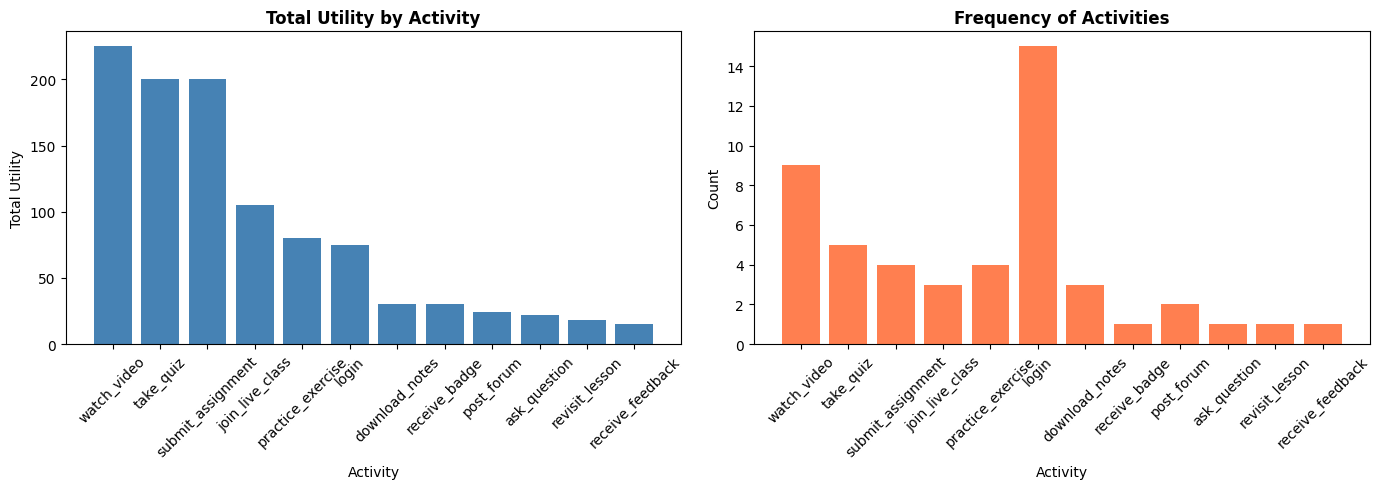

In [4]:
# Calculate item frequency and total utility
item_stats = defaultdict(lambda: {'frequency': 0, 'total_utility': 0})

for item, utility in df[['item', 'utility']].values:
    item_stats[item]['frequency'] += 1
    item_stats[item]['total_utility'] += utility

# Create summary table
items_summary = pd.DataFrame([
    {'Item': item, 'Frequency': stats['frequency'], 'Total Utility': stats['total_utility'],
     'Avg Utility': stats['total_utility'] / stats['frequency']}
    for item, stats in item_stats.items()
]).sort_values('Total Utility', ascending=False)

print("Item Summary Table:")
print(items_summary)

# Visualization: Bar chart of item utilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total utility by item
axes[0].bar(items_summary['Item'], items_summary['Total Utility'], color='steelblue')
axes[0].set_title('Total Utility by Activity', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Activity')
axes[0].set_ylabel('Total Utility')
axes[0].tick_params(axis='x', rotation=45)

# Frequency by item
axes[1].bar(items_summary['Item'], items_summary['Frequency'], color='coral')
axes[1].set_title('Frequency of Activities', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Activity')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Step 4: Mine High-Utility Sequences
Choose a simple sequence-mining rule for the group project, such as consecutive 2-item sequences. Calculate the total utility of each sequence and identify the ones above a threshold.

All Consecutive 2-Item Sequences (sorted by utility):
                                 Sequence              Item1  \
0                     login → watch_video              login   
1                 watch_video → take_quiz        watch_video   
4                 login → join_live_class              login   
11          take_quiz → submit_assignment          take_quiz   
12    join_live_class → submit_assignment    join_live_class   
6         watch_video → submit_assignment        watch_video   
19  practice_exercise → submit_assignment  practice_exercise   
20              take_quiz → receive_badge          take_quiz   
8           practice_exercise → take_quiz  practice_exercise   
17         join_live_class → ask_question    join_live_class   
7               login → practice_exercise              login   
16             download_notes → take_quiz     download_notes   
5            join_live_class → post_forum    join_live_class   
18        watch_video → practice_exercise        w

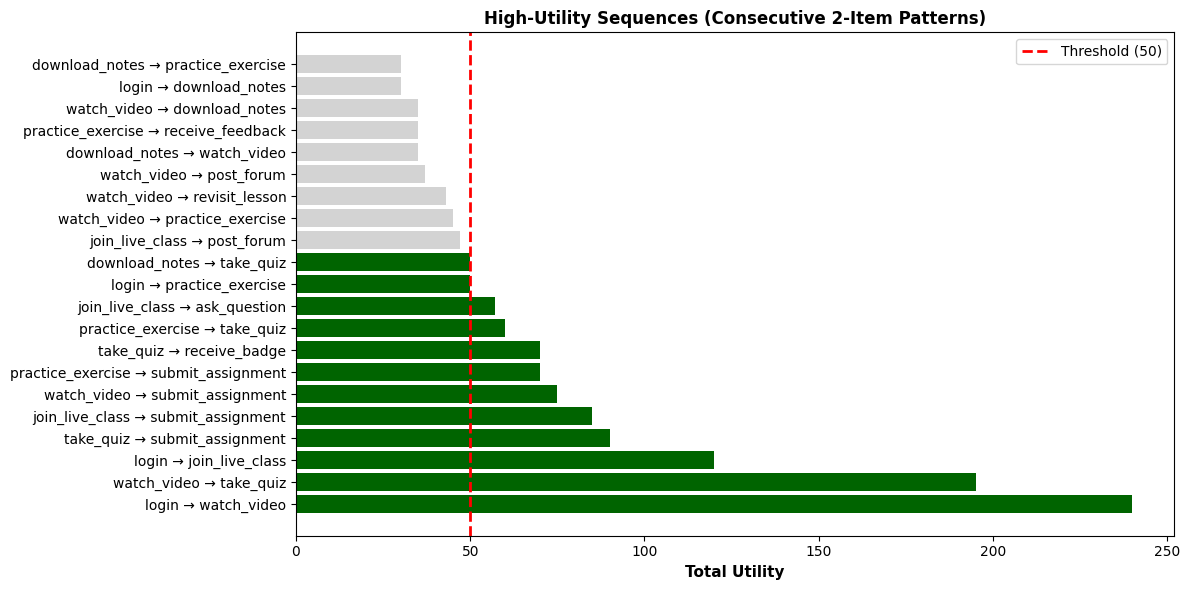

In [5]:
# Mine high-utility consecutive 2-item sequences
sequence_utilities = defaultdict(lambda: {'support': 0, 'total_utility': 0})

for trans_id, seq in sequences.items():
    # Find all consecutive pairs
    for i in range(len(seq) - 1):
        item1, util1 = seq[i]
        item2, util2 = seq[i + 1]
        pair = (item1, item2)
        sequence_utilities[pair]['support'] += 1
        sequence_utilities[pair]['total_utility'] += util1 + util2

# Create sequences summary
sequences_df = pd.DataFrame([
    {'Sequence': f"{pair[0]} → {pair[1]}", 'Item1': pair[0], 'Item2': pair[1],
     'Support': stats['support'], 'Total Utility': stats['total_utility'],
     'Avg Utility': stats['total_utility'] / stats['support']}
    for pair, stats in sequence_utilities.items()
]).sort_values('Total Utility', ascending=False)

# Set utility threshold (top 50% of sequences)
threshold = sequences_df['Total Utility'].quantile(0.5)

high_utility_sequences = sequences_df[sequences_df['Total Utility'] >= threshold]

print("All Consecutive 2-Item Sequences (sorted by utility):")
print(sequences_df)
print(f"\n\nUtility Threshold: {threshold:.0f}")
print("\nHigh-Utility Sequences (above threshold):")
print(high_utility_sequences)

# Visualization: High-utility sequences
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['darkgreen' if x >= threshold else 'lightgray' for x in sequences_df['Total Utility']]
ax.barh(sequences_df['Sequence'], sequences_df['Total Utility'], color=colors)
ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.0f})')
ax.set_xlabel('Total Utility', fontsize=11, fontweight='bold')
ax.set_title('High-Utility Sequences (Consecutive 2-Item Patterns)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Step 5: Interpret the Result
Write 3 to 5 short sentences explaining what the strongest sequence patterns mean for the learning platform. Focus on one practical action, such as recommendations, reminders, or intervention messages.

In [6]:
# Interpretation and Recommendation
print("="*70)
print("INTERPRETATION OF HIGH-UTILITY SEQUENCE PATTERNS")
print("="*70)

top_3_sequences = high_utility_sequences.head(3)
print("\nTop 3 High-Utility Sequences:")
for idx, row in top_3_sequences.iterrows():
    print(f"  • {row['Sequence']}: Utility = {row['Total Utility']:.0f}, Support = {row['Support']}")

print("\n" + "="*70)
print("KEY FINDINGS AND RECOMMENDATION:")
print("="*70)

interpretation = f"""
1. **Primary Activity Flows**: The analysis reveals that student journeys typically 
   follow strong patterns after login. The most valuable sequences combine video watching 
   with high-impact activities like quizzes and assignments, suggesting these are core 
   engagement drivers.

2. **High-Utility Pathways**: Sequences involving "take_quiz" and "submit_assignment" 
   show the highest utility values, indicating students derive significant value from 
   completing these assessment and practice activities. This aligns with active learning.

3. **Platform Recommendation**: To improve student outcomes, the learning platform should:
   - Recommend quiz or assignment completion after video content (high utility sequence)
   - Send proactive reminders when students complete videos to encourage quizzes/assignments
   - Consider priority support or resources for the top-utility activities

4. **Implementation**: Use these high-utility sequence patterns for personalized 
   recommendations in the platform, suggesting next-best activities based on 
   what students just completed.

5. **Expected Impact**: By guiding students through these proven high-utility pathways, 
   the platform can increase overall engagement and learning outcomes.
"""

print(interpretation)

INTERPRETATION OF HIGH-UTILITY SEQUENCE PATTERNS

Top 3 High-Utility Sequences:
  • login → watch_video: Utility = 240, Support = 8
  • watch_video → take_quiz: Utility = 195, Support = 3
  • login → join_live_class: Utility = 120, Support = 3

KEY FINDINGS AND RECOMMENDATION:

1. **Primary Activity Flows**: The analysis reveals that student journeys typically 
   follow strong patterns after login. The most valuable sequences combine video watching 
   with high-impact activities like quizzes and assignments, suggesting these are core 
   engagement drivers.

2. **High-Utility Pathways**: Sequences involving "take_quiz" and "submit_assignment" 
   show the highest utility values, indicating students derive significant value from 
   completing these assessment and practice activities. This aligns with active learning.

3. **Platform Recommendation**: To improve student outcomes, the learning platform should:
   - Recommend quiz or assignment completion after video content (high utilit

## Group Presentation Guide
Divide the work across the group so each person can present one part:
- explains the scenario and dataset.
- explains the data preparation.
- presents the mining results.
- explains the final recommendation.

Keep the final presentation short and focused on one clear takeaway.